In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Iris dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Iris dataset loaded successfully.
Features shape: (150, 4)
Target shape: (150,)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [3]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree classifier trained successfully.")

Decision Tree classifier trained successfully.


Accuracy Score: 1.00


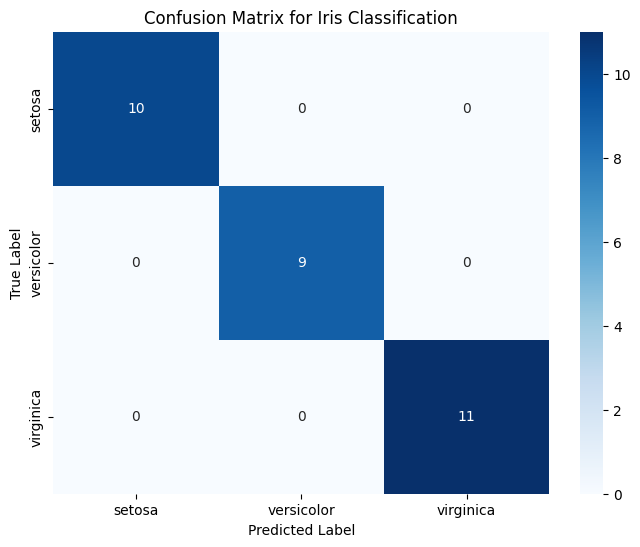

In [4]:
y_pred = dt_classifier.predict(X_test)

# Display accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}")

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Iris Classification')
plt.show()

Drug dataset loaded successfully.
Dataset shape: (200, 6)
First 5 rows of the dataset:
    Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY

Training data shape: (160, 6)
Testing data shape: (40, 6)

Decision Tree classifier trained successfully.

Accuracy Score: 1.00


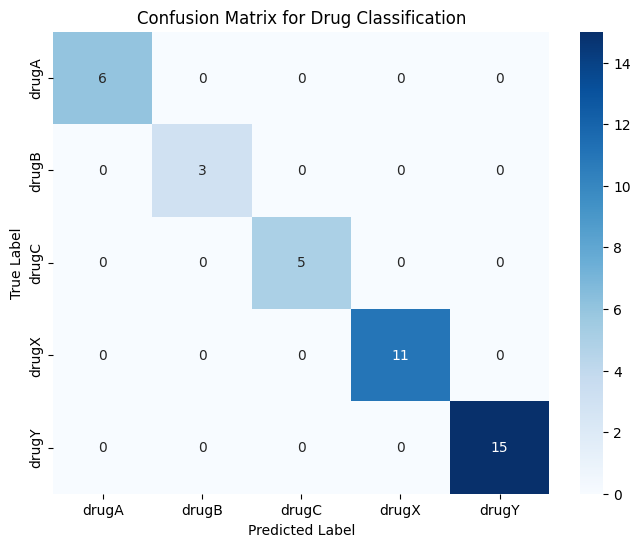

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Drug dataset
try:
    df = pd.read_csv('/content/drug.csv')
    print("Drug dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
    print("First 5 rows of the dataset:\n", df.head())
except FileNotFoundError:
    print("Error: 'drug.csv' not found. Please ensure the file is in the correct path.")
    exit()

# Separate features (X) and target (y)
X = df.drop('Drug', axis=1)
y = df['Drug']

# Handle categorical features using one-hot encoding
categorical_features = ['Sex', 'BP', 'Cholesterol'] # Assuming these are the categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Encode the target variable 'Drug' using LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Build and train a Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("\nDecision Tree classifier trained successfully.")

# Make predictions on the test data
y_pred = dt_classifier.predict(X_test)

# Display accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.2f}")

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Drug Classification')
plt.show()